In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
batch_size = 128
image_size = 64
z_dim = 100
num_epochs = 5
lr = 0.0002
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = torchvision.datasets.CIFAR10(root='./data', download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 170M/170M [06:10<00:00, 460kB/s] 


In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
gen = Generator().to(device)
disc = Discriminator().to(device)

criterion = nn.BCELoss()
opt_gen = torch.optim.Adam(gen.parameters(), lr=lr)
opt_disc = torch.optim.Adam(disc.parameters(), lr=lr)

In [7]:
for epoch in range(num_epochs):
    for real, _ in loader:
        real = real.to(device)
        batch_size = real.shape[0]

        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)

        # Train Discriminator
        disc_real = disc(real).reshape(-1)
        loss_real = criterion(disc_real, torch.ones_like(disc_real))

        disc_fake = disc(fake.detach()).reshape(-1)
        loss_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

        loss_disc = (loss_real + loss_fake) / 2
        opt_disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        # Train Generator
        output = disc(fake).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

    print(f"Epoch [{epoch}/{num_epochs}] Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

Epoch [0/5] Loss D: 0.0007, Loss G: 8.3274
Epoch [1/5] Loss D: 0.0001, Loss G: 9.5481
Epoch [2/5] Loss D: 0.0000, Loss G: 10.7429
Epoch [3/5] Loss D: 0.0000, Loss G: 11.4638
Epoch [4/5] Loss D: 0.0000, Loss G: 10.7413


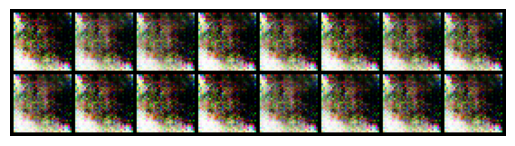

In [8]:
def show_images(images):
    grid = torchvision.utils.make_grid(images[:16], normalize=True)
    plt.imshow(np.transpose(grid.cpu(), (1,2,0)))
    plt.axis("off")
    plt.show()

noise = torch.randn(16, z_dim, 1, 1).to(device)
fake_images = gen(noise)

show_images(fake_images)

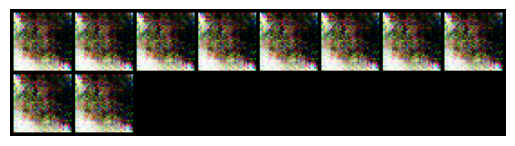

In [9]:
z1 = torch.randn(1, z_dim, 1, 1).to(device)
z2 = torch.randn(1, z_dim, 1, 1).to(device)

alphas = torch.linspace(0, 1, steps=10)

images = []
for alpha in alphas:
    z = alpha * z1 + (1 - alpha) * z2
    img = gen(z)
    images.append(img)

images = torch.cat(images)
show_images(images)